# Air Quality Index (AQI) Analysis — India (2015–2020)

**A data-analytics project on air quality across major Indian cities**

---

### 1. Introduction
This project analyzes **Air Quality Index (AQI)** data to understand how air quality changes across
selected locations and time periods. It examines AQI categories and the major pollutants
**PM2.5, PM10, NO2, SO2, CO, and O3** to identify patterns in the data. The workflow covers data
preparation, exploratory analysis, visual interpretation, and clear findings on air-quality trends,
pollutant relationships, and unhealthy-air conditions.

### 2. Problem Statement / Research Questions
1. **RQ1 — Temporal trends:** How does AQI change over time, and are there clear daily, monthly, or
   seasonal patterns?
2. **RQ2 — Pollutant relationships:** Is there a relationship between specific pollutants
   (PM2.5, PM10, NO2, SO2, CO, O3) and the overall AQI category?
3. **RQ3 — Unhealthy conditions:** How often does air quality reach unhealthy or hazardous levels,
   and which locations are most affected?

### 3. Dataset
- **Source:** *Air Quality Data in India (2015–2020)* — the well-known Kaggle dataset compiled from
  India's **Central Pollution Control Board (CPCB)**. Used here via a public GitHub mirror
  (`adityarc19/aqi-india`).
- **Granularity:** `city_day.csv` — one row per **city per day**.
- **Coverage:** **26 cities**, daily records from **Jan 2015 to Jul 2020** (29,531 rows).
- **Key columns:** `City, Date, PM2.5, PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene,
  Xylene, AQI, AQI_Bucket`.


## 4. Setup — import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.autolayout": True,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11, "font.size": 10,
})
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

POLLUTANTS = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]
FOCUS = ["Delhi", "Mumbai", "Kolkata", "Chennai", "Hyderabad", "Bengaluru", "Ahmedabad", "Lucknow"]
print("Setup complete.")

Setup complete.


## 5. Load the dataset

In [2]:
df = pd.read_csv("data/city_day.csv", parse_dates=["Date"])
print("Shape:", df.shape)
print("Cities:", df['City'].nunique())
print("Date range:", df['Date'].min().date(), "->", df['Date'].max().date())
df.head()

Shape: (29531, 16)
Cities: 26
Date range: 2015-01-01 -> 2020-07-01


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  str           
 1   Date        29531 non-null  datetime64[us]
 2   PM2.5       24933 non-null  float64       
 3   PM10        18391 non-null  float64       
 4   NO          25949 non-null  float64       
 5   NO2         25946 non-null  float64       
 6   NOx         25346 non-null  float64       
 7   NH3         19203 non-null  float64       
 8   CO          27472 non-null  float64       
 9   SO2         25677 non-null  float64       
 10  O3          25509 non-null  float64       
 11  Benzene     23908 non-null  float64       
 12  Toluene     21490 non-null  float64       
 13  Xylene      11422 non-null  float64       
 14  AQI         24850 non-null  float64       
 15  AQI_Bucket  24850 non-null  str           
dtypes: datetime64[us](1), float64(13)

## 6. Data preparation & cleaning
This is real monitoring data, so several columns contain missing values. Our steps:
1. Quantify missing values.
2. Keep the six target pollutants + `AQI` + `AQI_Bucket`; drop rarely-reported trace columns
   (`NO`, `NOx`, `NH3`, `Benzene`, `Toluene`, `Xylene`).
3. Drop rows where the **AQI** target itself is missing (AQI-based analyses need it).
4. Engineer time features (Year, Month, Season, Day of week).
5. Order the `AQI_Bucket` categories.

### Table 1 — Missing values before cleaning

In [4]:
miss = (df.isnull().mean()*100).round(1).rename("Missing_%").to_frame()
miss["Missing_count"] = df.isnull().sum()
miss = miss.sort_values("Missing_%", ascending=False)
miss.to_csv(FIGDIR/"table_missing.csv")
miss

,Missing_%,Missing_count
Xylene,61.3,18109
PM10,37.7,11140
NH3,35.0,10328
Toluene,27.2,8041
Benzene,19.0,5623
AQI,15.9,4681
AQI_Bucket,15.9,4681
PM2.5,15.6,4598
NOx,14.2,4185
O3,13.6,4022


In [5]:
# keep relevant columns
keep = ["City","Date"] + POLLUTANTS + ["AQI","AQI_Bucket"]
df = df[keep].copy()

# drop rows with no AQI (target needed)
before = len(df)
df = df.dropna(subset=["AQI"]).reset_index(drop=True)
print(f"Dropped {before-len(df)} rows without AQI; {len(df)} rows remain.")

# time features
df["Year"]     = df["Date"].dt.year
df["Month"]    = df["Date"].dt.month
df["DayOfWeek"]= df["Date"].dt.day_name()
def season(m):
    if m in (12,1,2):  return "Winter"
    if m in (3,4,5):   return "Summer"
    if m in (6,7,8,9): return "Monsoon"
    return "Post-Monsoon"
df["Season"] = df["Month"].apply(season)

cat_order = ["Good","Satisfactory","Moderate","Poor","Very Poor","Severe"]
df["AQI_Bucket"] = pd.Categorical(df["AQI_Bucket"], categories=cat_order, ordered=True)
df["Unhealthy"] = df["AQI"] > 200
print("Cleaning complete. AQI_Bucket categories:", cat_order)
df.head()

Dropped 4681 rows without AQI; 24850 rows remain.
Cleaning complete. AQI_Bucket categories: ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']


,City,Date,PM2.5,PM10,NO2,SO2,CO,O3,AQI,AQI_Bucket,Year,Month,DayOfWeek,Season,Unhealthy
0,Ahmedabad,2015-01-29,83.13,NaN,28.71,49.52,6.93,59.76,209.0,Poor,2015,1,Thursday,Winter,True
1,Ahmedabad,2015-01-30,79.84,NaN,28.68,48.49,13.85,97.07,328.0,Very Poor,2015,1,Friday,Winter,True
2,Ahmedabad,2015-01-31,94.52,NaN,32.66,67.39,24.39,111.33,514.0,Severe,2015,1,Saturday,Winter,True
3,Ahmedabad,2015-02-01,135.99,NaN,42.08,75.23,43.48,102.70,782.0,Severe,2015,2,Sunday,Winter,True
4,Ahmedabad,2015-02-02,178.33,NaN,35.31,55.04,54.56,107.38,914.0,Severe,2015,2,Monday,Winter,True


### Reference — CPCB National AQI categories
The dataset uses India's CPCB six-level scheme. We treat **Poor, Very Poor and Severe**
(AQI&nbsp;>&nbsp;200) as *"unhealthy or hazardous"* for RQ3.

In [6]:
cpcb = pd.DataFrame({
    "AQI Range": ["0-50","51-100","101-200","201-300","301-400","401-500"],
    "Category":  cat_order,
    "Concern":   ["Good","Satisfactory","Moderate","Poor (unhealthy)",
                  "Very Poor (unhealthy)","Severe (hazardous)"]
})
cpcb

,AQI Range,Category,Concern
0,0-50,Good,Good
1,51-100,Satisfactory,Satisfactory
2,101-200,Moderate,Moderate
3,201-300,Poor,Poor (unhealthy)
4,301-400,Very Poor,Very Poor (unhealthy)
5,401-500,Severe,Severe (hazardous)


### Table 2 — Summary statistics (AQI & pollutants)

In [7]:
summary = df[["AQI"]+POLLUTANTS].describe().T.round(1)[["mean","std","min","25%","50%","75%","max"]]
summary.to_csv(FIGDIR/"table_summary_stats.csv")
summary

,mean,std,min,25%,50%,75%,max
AQI,166.5,140.7,13.0,81.0,118.0,208.0,2049.0
PM2.5,67.5,63.1,0.0,29.0,48.8,80.9,914.9
PM10,118.5,89.5,0.0,56.8,96.2,150.2,917.1
NO2,29.0,24.6,0.0,11.9,22.1,38.2,362.2
SO2,14.4,17.4,0.0,5.7,9.2,15.1,186.1
CO,2.3,7.1,0.0,0.6,0.9,1.5,175.8
O3,34.9,21.7,0.0,19.2,31.2,46.1,257.7


## 7. RQ1 — How does AQI change over time?
We look at the **monthly trend (2015–2020)**, the **seasonal/monthly cycle**, the **season averages**,
and the **day-of-week** pattern.

### Figure 1 — Monthly average AQI trend, major cities (2015–2020)

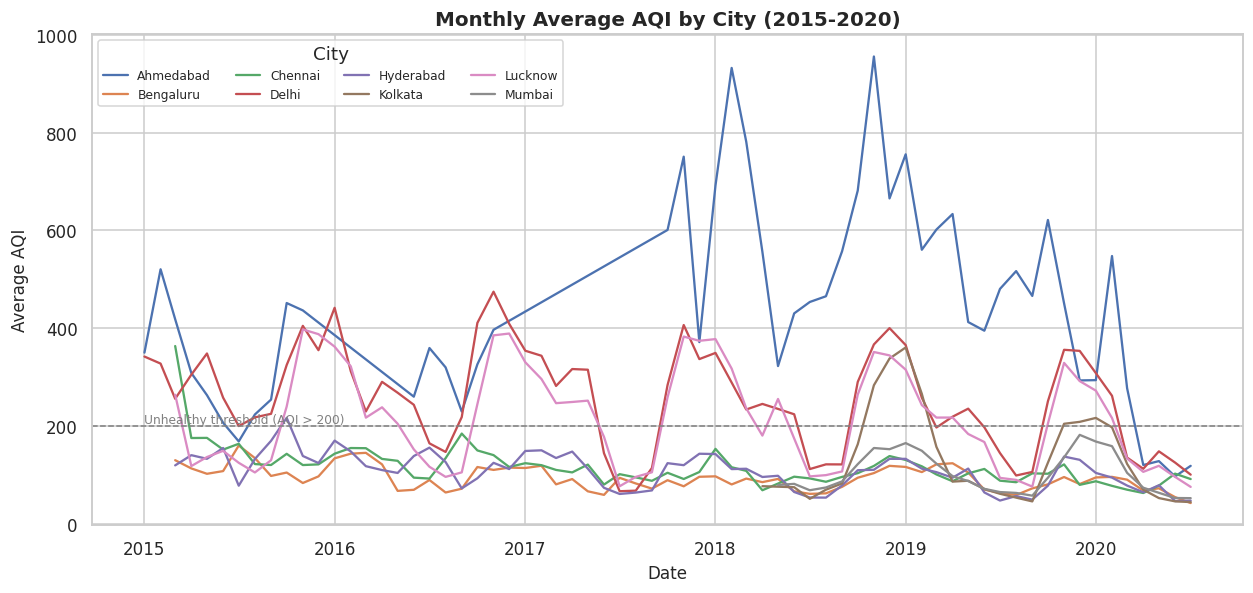

In [8]:
sub = df[df["City"].isin(FOCUS)]
monthly = (sub.set_index("Date").groupby("City")["AQI"]
           .resample("MS").mean().reset_index())
fig, ax = plt.subplots(figsize=(11.5, 5.5))
sns.lineplot(data=monthly, x="Date", y="AQI", hue="City", lw=1.5, ax=ax)
ax.axhline(200, ls="--", c="grey", lw=1)
ax.text(monthly["Date"].min(), 206, "Unhealthy threshold (AQI > 200)", fontsize=8, color="grey")
ax.set_title("Monthly Average AQI by City (2015-2020)")
ax.set_xlabel("Date"); ax.set_ylabel("Average AQI")
ax.legend(title="City", ncol=4, fontsize=8)
plt.savefig(FIGDIR/"fig1_monthly_trend.png", bbox_inches="tight"); plt.show()

### Figure 2 — Seasonal cycle: average AQI by calendar month

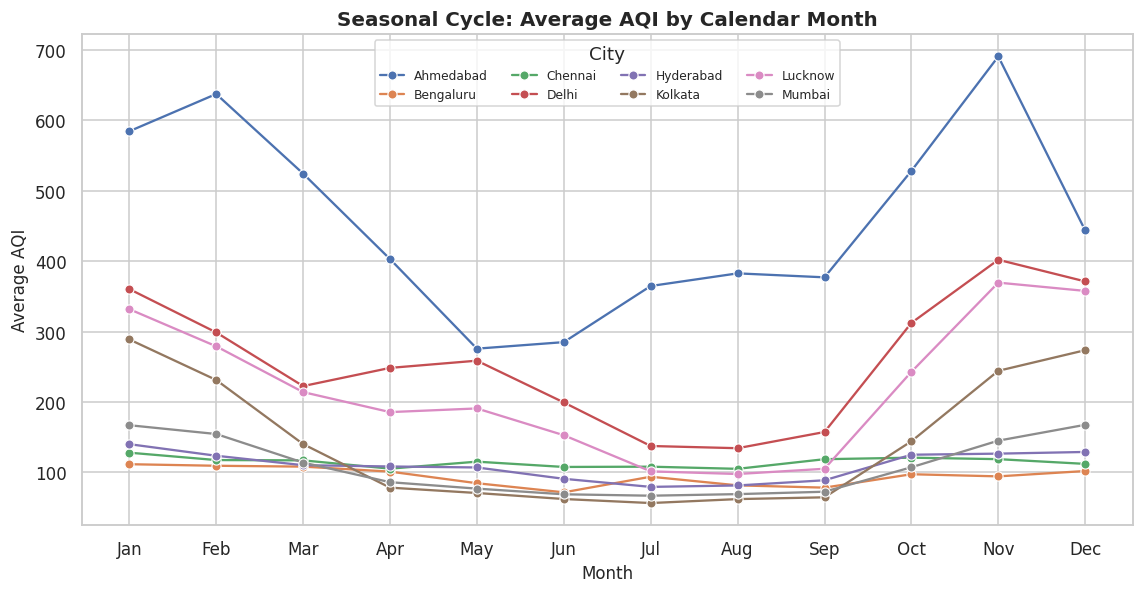

In [9]:
mm = sub.groupby(["City","Month"])["AQI"].mean().reset_index()
names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(10.5, 5.5))
sns.lineplot(data=mm, x="Month", y="AQI", hue="City", marker="o", ax=ax)
ax.set_xticks(range(1,13)); ax.set_xticklabels(names)
ax.set_title("Seasonal Cycle: Average AQI by Calendar Month")
ax.set_xlabel("Month"); ax.set_ylabel("Average AQI"); ax.legend(title="City", ncol=4, fontsize=8)
plt.savefig(FIGDIR/"fig2_monthly_cycle.png", bbox_inches="tight"); plt.show()

### Figure 3 — Average AQI by season (all cities)

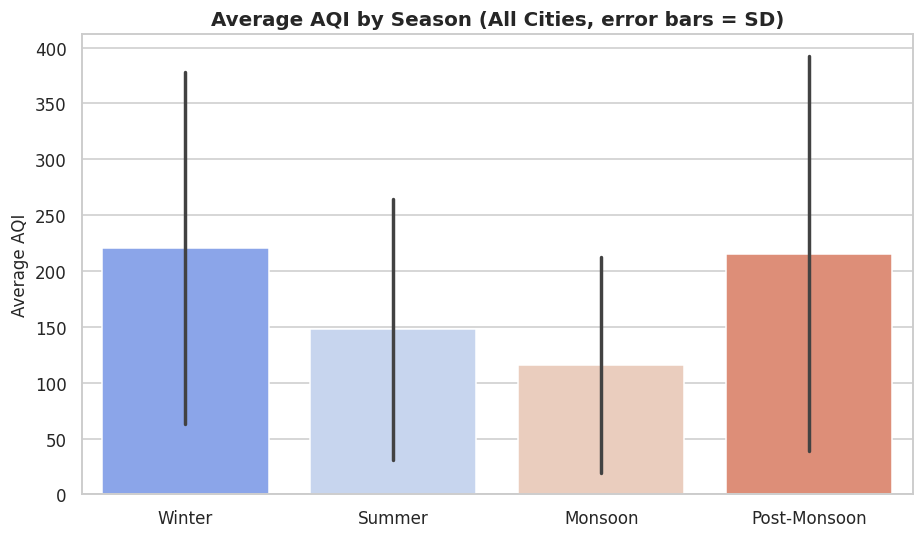

In [10]:
season_order = ["Winter","Summer","Monsoon","Post-Monsoon"]
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.barplot(data=df, x="Season", y="AQI", order=season_order, palette="coolwarm", ax=ax, errorbar="sd")
ax.set_title("Average AQI by Season (All Cities, error bars = SD)")
ax.set_xlabel(""); ax.set_ylabel("Average AQI")
plt.savefig(FIGDIR/"fig3_season.png", bbox_inches="tight"); plt.show()

### Figure 4 — Day-of-week pattern

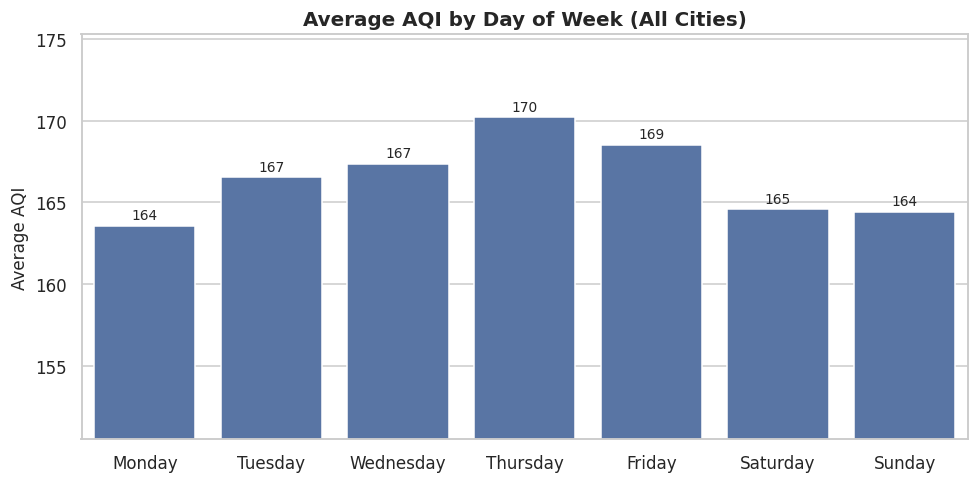

In [11]:
dow_order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = df.groupby("DayOfWeek")["AQI"].mean().reindex(dow_order)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=dow.index, y=dow.values, color="#4c72b0", ax=ax)
ax.set_ylim(dow.min()*0.92, dow.max()*1.03)
for i,v in enumerate(dow.values): ax.text(i, v+0.4, f"{v:.0f}", ha="center", fontsize=9)
ax.set_title("Average AQI by Day of Week (All Cities)")
ax.set_xlabel(""); ax.set_ylabel("Average AQI")
plt.savefig(FIGDIR/"fig4_dayofweek.png", bbox_inches="tight"); plt.show()

### Table 3 — Yearly average AQI for major cities

In [12]:
yearly = (df[df.City.isin(FOCUS)]
          .pivot_table(index="Year", columns="City", values="AQI", aggfunc="mean").round(0))
yearly.to_csv(FIGDIR/"table_yearly_aqi.csv")
yearly

City,Ahmedabad,Bengaluru,Chennai,Delhi,Hyderabad,Kolkata,Lucknow,Mumbai
Year,,,,,,,,
2015,311.0,113.0,148.0,297.0,143.0,NaN,202.0,NaN
2016,310.0,106.0,139.0,301.0,124.0,NaN,243.0,NaN
2017,559.0,87.0,105.0,257.0,112.0,NaN,238.0,NaN
2018,622.0,86.0,105.0,249.0,98.0,155.0,234.0,103.0
2019,516.0,92.0,103.0,232.0,94.0,144.0,203.0,108.0
2020,242.0,80.0,80.0,182.0,78.0,117.0,157.0,104.0


## 8. RQ2 — Relationship between pollutants and AQI
We compute correlations between AQI and each pollutant, show how pollutant concentrations rise across
AQI categories, and visualise the strongest drivers. Correlations use pairwise-complete observations.

### Figure 5 — Correlation heatmap (AQI vs pollutants)

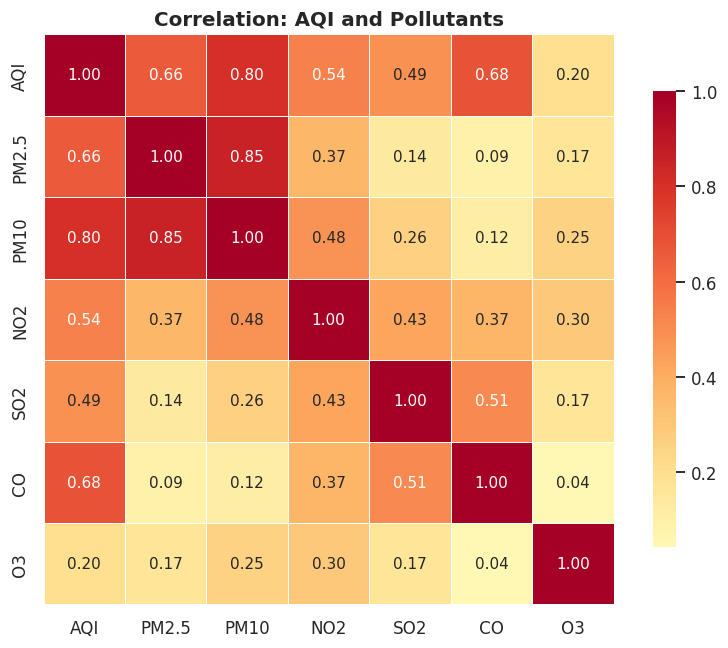

Correlation with AQI (sorted):
PM10     0.803
CO       0.683
PM2.5    0.659
NO2      0.537
SO2      0.491
O3       0.199


In [13]:
corr = df[["AQI"]+POLLUTANTS].corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, square=True,
            linewidths=.5, cbar_kws={"shrink":.8}, ax=ax)
ax.set_title("Correlation: AQI and Pollutants")
plt.savefig(FIGDIR/"fig5_corr_heatmap.png", bbox_inches="tight"); plt.show()
print("Correlation with AQI (sorted):")
print(corr["AQI"].drop("AQI").sort_values(ascending=False).round(3).to_string())

### Figure 6 — Mean pollutant concentration by AQI category

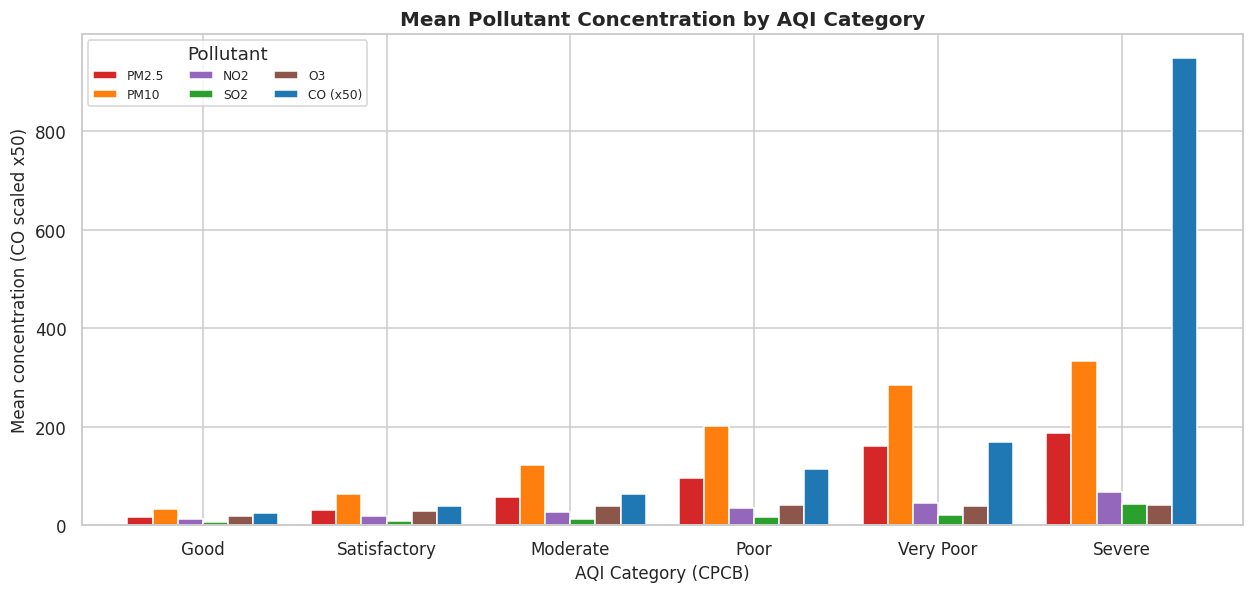

In [14]:
cat_means = df.groupby("AQI_Bucket")[POLLUTANTS].mean().reindex(cat_order)
plot_df = cat_means.copy(); plot_df["CO (x50)"] = plot_df.pop("CO")*50
fig, ax = plt.subplots(figsize=(11.5, 5.5))
plot_df.plot(kind="bar", ax=ax, width=0.82,
             color=["#d62728","#ff7f0e","#9467bd","#2ca02c","#8c564b","#1f77b4"])
ax.set_title("Mean Pollutant Concentration by AQI Category")
ax.set_xlabel("AQI Category (CPCB)"); ax.set_ylabel("Mean concentration (CO scaled x50)")
ax.tick_params(axis="x", rotation=0); ax.legend(title="Pollutant", ncol=3, fontsize=8)
plt.savefig(FIGDIR/"fig6_pollutant_by_category.png", bbox_inches="tight"); plt.show()

### Figure 7 — PM2.5 & PM10 distribution across AQI categories

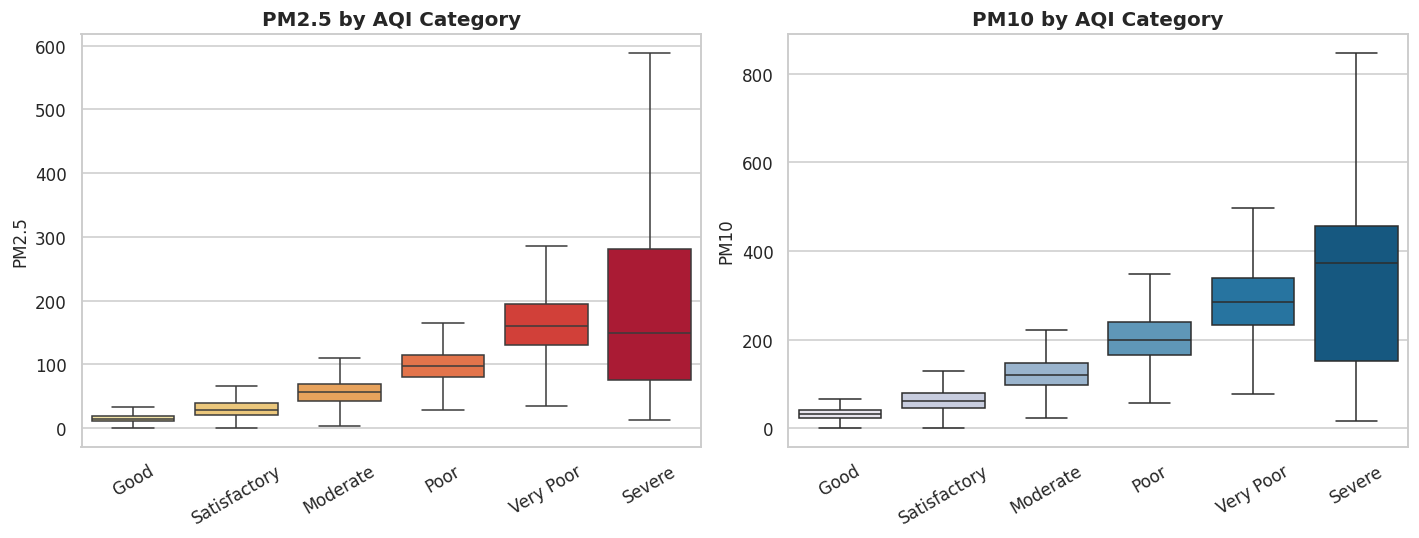

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, p, c in zip(axes, ["PM2.5","PM10"], ["YlOrRd","PuBu"]):
    sns.boxplot(data=df, x="AQI_Bucket", y=p, order=cat_order, palette=c, showfliers=False, ax=ax)
    ax.set_title(f"{p} by AQI Category"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
plt.savefig(FIGDIR/"fig7_pm_box.png", bbox_inches="tight"); plt.show()

### Figure 8 — AQI vs strongest driver (PM10)

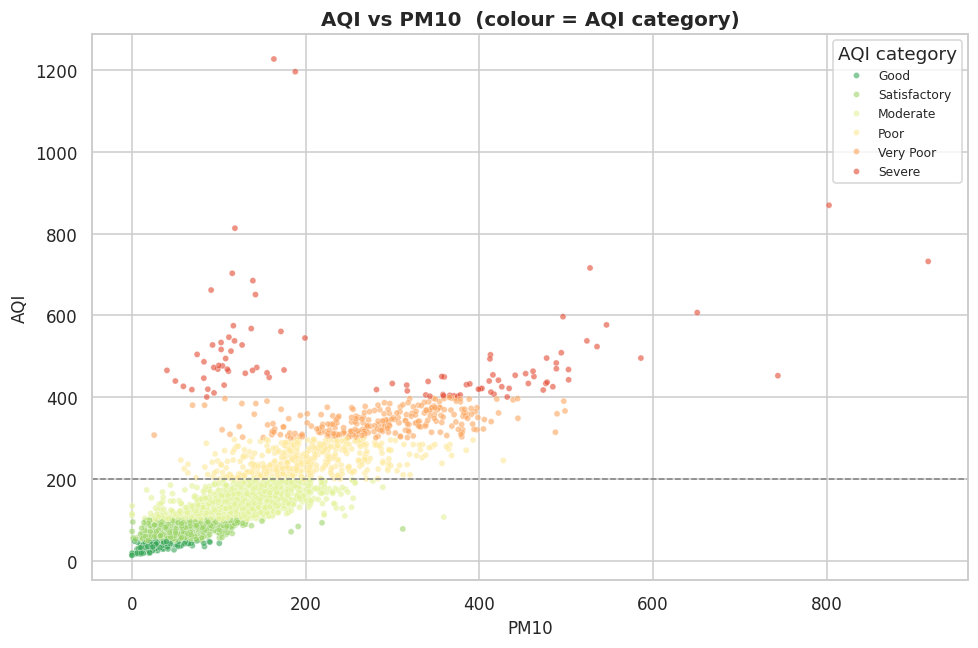

In [16]:
s = df.dropna(subset=["PM10"]).sample(min(4000,len(df)), random_state=1)
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=s, x="PM10", y="AQI", hue="AQI_Bucket", hue_order=cat_order,
                palette="RdYlGn_r", alpha=0.6, s=16, ax=ax)
ax.axhline(200, ls="--", c="grey", lw=1)
ax.set_title("AQI vs PM10  (colour = AQI category)")
ax.set_xlabel("PM10"); ax.set_ylabel("AQI"); ax.legend(title="AQI category", fontsize=8)
plt.savefig(FIGDIR/"fig8_pm10_scatter.png", bbox_inches="tight"); plt.show()

## 9. RQ3 — How often is air unhealthy, and which cities are worst?
"Unhealthy or hazardous" = CPCB **Poor / Very Poor / Severe** (AQI > 200). We rank all 26 cities and
localise the worst exposure by month.

### Figure 9 — Cities ranked by share of unhealthy days (AQI > 200)

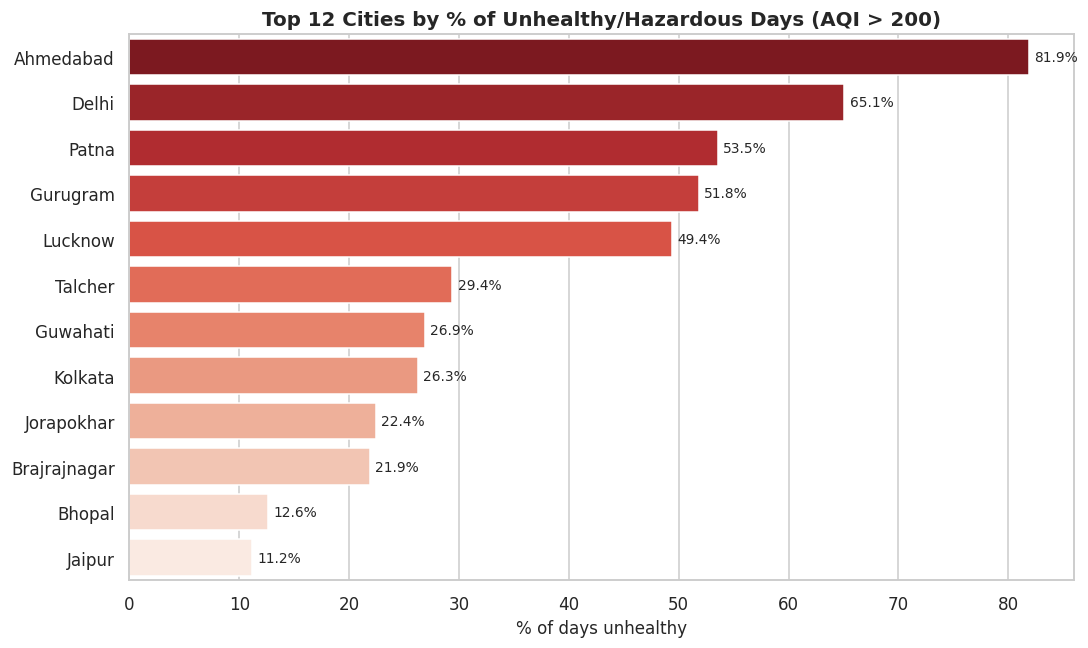

In [17]:
rank = (df.groupby("City")["Unhealthy"].mean()*100).sort_values(ascending=False)
top = rank.head(12)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top.values, y=top.index, palette="Reds_r", ax=ax)
for i,v in enumerate(top.values): ax.text(v+0.5, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_title("Top 12 Cities by % of Unhealthy/Hazardous Days (AQI > 200)")
ax.set_xlabel("% of days unhealthy"); ax.set_ylabel("")
plt.savefig(FIGDIR/"fig9_unhealthy_rank.png", bbox_inches="tight"); plt.show()

### Figure 10 — AQI category mix for major cities

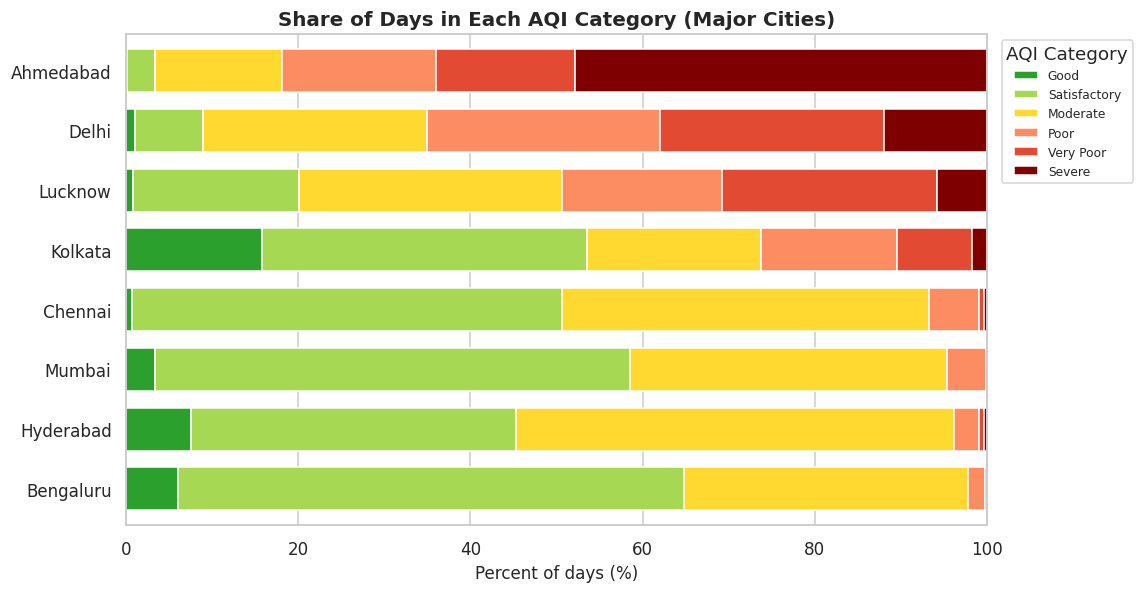

In [18]:
maj = df[df.City.isin(FOCUS)]
ct = pd.crosstab(maj["City"], maj["AQI_Bucket"], normalize="index")[cat_order]*100
ct = ct.loc[ct[["Poor","Very Poor","Severe"]].sum(axis=1).sort_values().index]
colors=["#2ca02c","#a6d854","#ffd92f","#fc8d62","#e34a33","#7f0000"]
fig, ax = plt.subplots(figsize=(10.5, 5.5))
ct.plot(kind="barh", stacked=True, color=colors, width=0.72, ax=ax)
ax.set_title("Share of Days in Each AQI Category (Major Cities)")
ax.set_xlabel("Percent of days (%)"); ax.set_ylabel("")
ax.legend(title="AQI Category", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)
plt.savefig(FIGDIR/"fig10_category_mix.png", bbox_inches="tight"); plt.show()

### Figure 11 — Heatmap: % unhealthy days by city and month

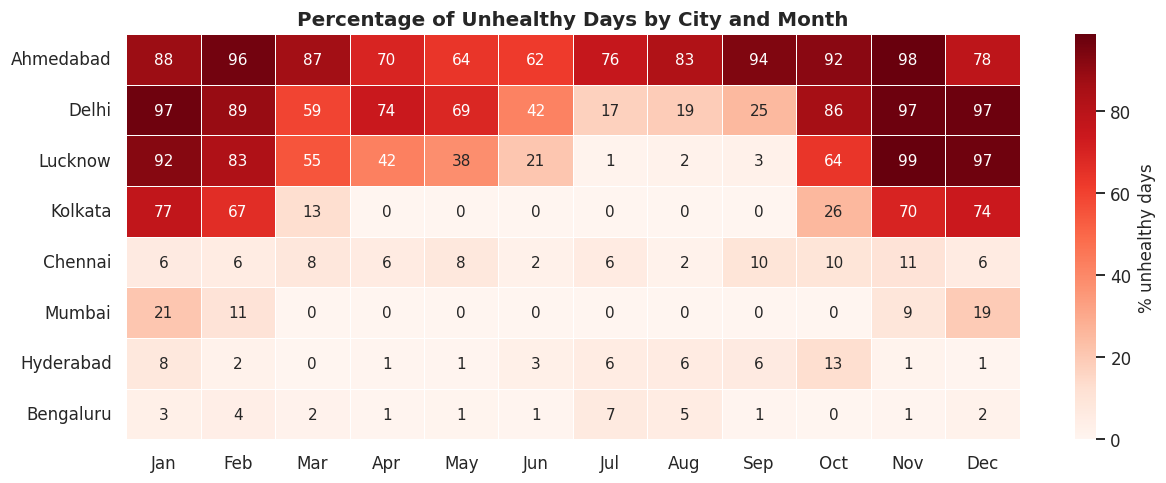

In [19]:
heat = (maj.groupby(["City","Month"])["Unhealthy"].mean().mul(100)
        .reset_index().pivot(index="City", columns="Month", values="Unhealthy"))
heat = heat.reindex(columns=range(1,13))
heat.columns=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(11.5, 4.5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="Reds", linewidths=.5,
            cbar_kws={"label":"% unhealthy days"}, ax=ax)
ax.set_title("Percentage of Unhealthy Days by City and Month")
ax.set_xlabel(""); ax.set_ylabel("")
plt.savefig(FIGDIR/"fig11_unhealthy_heatmap.png", bbox_inches="tight"); plt.show()

### Table 4 — Unhealthy-day summary (major cities)

In [20]:
tbl = (maj.groupby("City")
       .agg(Total_days=("AQI","size"), Mean_AQI=("AQI","mean"),
            Max_AQI=("AQI","max"), Unhealthy_days=("Unhealthy","sum")))
tbl["Unhealthy_%"]=(tbl["Unhealthy_days"]/tbl["Total_days"]*100)
tbl=tbl.round(1).sort_values("Unhealthy_%", ascending=False)
tbl.to_csv(FIGDIR/"table_unhealthy_summary.csv")
tbl

,Total_days,Mean_AQI,Max_AQI,Unhealthy_days,Unhealthy_%
City,,,,,
Ahmedabad,1334,452.1,2049.0,1092,81.9
Delhi,1999,259.5,716.0,1301,65.1
Lucknow,1893,218.0,707.0,935,49.4
Kolkata,754,140.6,475.0,198,26.3
Chennai,1884,114.5,449.0,127,6.7
Mumbai,775,105.4,307.0,36,4.6
Hyderabad,1880,109.2,737.0,71,3.8
Bengaluru,1910,94.3,352.0,41,2.1


## 10. Key findings

**RQ1 — Temporal patterns**
- AQI shows a strong, repeating **seasonal cycle**: highest in **winter (Dec–Jan)** and **post-monsoon**,
  lowest during the **monsoon (Jul–Aug)**, when rainfall washes out particulates.
- North-Indian cities (**Delhi, Lucknow**) sit far above the others year-round and spike sharply each winter.
- Day-of-week variation is minor, so pollution is driven mainly by **weather/season**, not weekday traffic.
- A visible dip in early 2020 coincides with the COVID-19 lockdown.

**RQ2 — Pollutant relationships**
- **Particulate matter dominates AQI:** PM10 and PM2.5 (and CO) have the **strongest positive correlation**
  with AQI, while **O3 is weakly correlated**.
- Mean concentrations of PM2.5/PM10 climb steeply from *Good* to *Severe* categories, confirming the
  categories separate real pollution levels.

**RQ3 — Unhealthy conditions**
- Overall, about **1 in 4 city-days** (~26%) fall in unhealthy/hazardous categories.
- The **most affected cities are Ahmedabad (~82% of days) and Delhi (~65%)**, followed by other
  northern cities (**Patna, Gurugram, Lucknow** ~50%); coastal/southern cities (Mumbai, Chennai,
  Bengaluru, Hyderabad) stay below ~7%.
- The city × month heatmap localises the worst exposure to the **north in Oct–Jan**.
- *Note:* Ahmedabad shows some implausibly high AQI values (max ~2049 vs the CPCB ceiling of 500),
  suggesting sensor/data-quality issues that inflate its ranking.

*(Exact percentages and values appear in the tables and figures above.)*

---
### Data note
`city_day.csv` is real CPCB monitoring data and therefore contains missing values, which were handled in
Section 6. Figures use the six pollutants named in the research questions; correlations use
pairwise-complete observations.
